In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parameters for the symmetric Gaussians
mu = 2.2   # distance from y=0
sigma = 5
x = np.linspace(-16, 16, 1000)

# Two symmetric Gaussian PDFs
pdf_left = norm.pdf(x, -mu, sigma)
pdf_right = norm.pdf(x, mu, sigma)

# Log ratio of PDFs
log_ratio = np.log10(pdf_right / pdf_left)

# Define target log ratio values
target_log_ratios = np.array([-0.9, -0.7, -0.5, -0.3, 0.3, 0.5, 0.7, 0.9])
# target_log_ratios = np.linspace(-0.9, 0.9, 8)

# Find corresponding x values by interpolation
x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

# Normalize
pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

pA = [0.0541 0.1286 0.2323 0.3191 0.1599 0.0735 0.0257 0.0068]
pB = [0.0068 0.0257 0.0735 0.1599 0.3191 0.2323 0.1286 0.0541]

Predictability matrix M[i,j] = P(next=j | observed=i):
[[0.0488 0.1171 0.2145 0.3013 0.1777 0.0912 0.0372 0.0121]
 [0.0463 0.1115 0.2059 0.2926 0.1864 0.0999 0.0428 0.0147]
 [0.0428 0.1039 0.1941 0.2809 0.1982 0.1116 0.0504 0.0182]
 [0.0383 0.0942 0.1793 0.266  0.2131 0.1265 0.06   0.0226]
 [0.0226 0.06   0.1265 0.2131 0.266  0.1793 0.0942 0.0383]
 [0.0182 0.0504 0.1116 0.1982 0.2809 0.1941 0.1039 0.0428]
 [0.0147 0.0428 0.0999 0.1864 0.2926 0.2059 0.1115 0.0463]
 [0.0121 0.0372 0.0912 0.1777 0.3013 0.2145 0.1171 0.0488]]


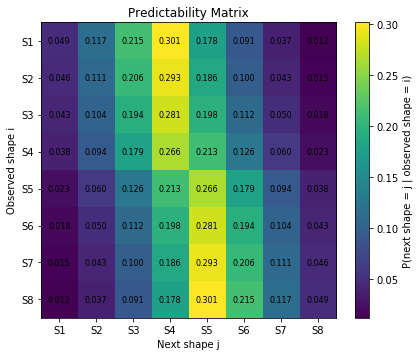

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Recreate pA and pB from your script
# -----------------------------
mu = 2.2
sigma = 5
x = np.linspace(-16, 16, 1000)

pdf_left = norm.pdf(x, -mu, sigma)   # Target A
pdf_right = norm.pdf(x,  mu, sigma)  # Target B

log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([-0.9, -0.7, -0.5, -0.3, 0.3, 0.5, 0.7, 0.9])
x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets,  mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pA = pA_raw / pA_raw.sum()
pB = pB_raw / pB_raw.sum()

# Optional shape labels
shape_labels = [f"S{i+1}" for i in range(8)]

# -----------------------------
# Predictability matrix
# M[i, j] = P(next shape = j | observed shape = i)
# -----------------------------
prior_A = 0.5
prior_B = 0.5

# Posterior over bag identity after observing shape i
post_A = (prior_A * pA) / (prior_A * pA + prior_B * pB)
post_B = 1.0 - post_A

# Build 8x8 conditional prediction matrix
# Row i: observed shape i
# Col j: probability next draw is shape j
M = np.outer(post_A, pA) + np.outer(post_B, pB)

# -----------------------------
# Print matrix
# -----------------------------
np.set_printoptions(precision=4, suppress=True)
print("pA =", pA)
print("pB =", pB)
print("\nPredictability matrix M[i,j] = P(next=j | observed=i):")
print(M)

# -----------------------------
# Plot heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(M, aspect='equal', interpolation='nearest')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('P(next shape = j | observed shape = i)')

ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels(shape_labels)
ax.set_yticklabels(shape_labels)

ax.set_xlabel('Next shape j')
ax.set_ylabel('Observed shape i')
ax.set_title('Predictability Matrix')

# Put numeric values in each cell
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.3f}",
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()